In [2]:
from google.colab import files
uploaded = files.upload()

import zipfile
import os

with zipfile.ZipFile('repolens_all_metrics.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

Saving repolens_all_metrics.zip to repolens_all_metrics (1).zip


In [31]:
import os
import pandas as pd

base_path = 'data'

repo_tables = {}

# STEP 1: Load + organize
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.csv'):
            path = os.path.join(root, file)

            repo_name = path.split('/')[1]
            method = file.replace('.csv', '')

            df = pd.read_csv(path)
            df['method'] = method

            if repo_name not in repo_tables:
                repo_tables[repo_name] = []

            repo_tables[repo_name].append(df)

# STEP 2: Combine per repo
final_tables = {}
for repo, dfs in repo_tables.items():
    final_tables[repo] = pd.concat(dfs, ignore_index=True)

# STEP 3: Aggregate metrics
summary_tables = {}

for repo, df in final_tables.items():
    summary = df.groupby('method').agg({
        'f1': 'mean',
        'precision': 'mean',
        'recall': 'mean',
        'tp': 'sum',
        'fp': 'sum',
        'fn': 'sum',
        'coverage': 'mean'
    }).reset_index()

    summary_tables[repo] = summary

# STEP 4: Export results
output_dir = 'results'
os.makedirs(output_dir, exist_ok=True)

# Save FULL combined tables
for repo, table in final_tables.items():
    file_path = os.path.join(output_dir, f"{repo}_full.csv")
    table.to_csv(file_path, index=False)

# Save SUMMARY tables
for repo, table in summary_tables.items():
    file_path = os.path.join(output_dir, f"{repo}_summary.csv")
    table.to_csv(file_path, index=False)

print("Done. Full tables + summaries saved.")

Done. Full tables + summaries saved.


In [32]:
import numpy as np

rows = []

for repo, df in final_tables.items():
    # filter at τ = 0.1 safely
    df_tau = df[np.isclose(df['threshold'], 0.1)]

    for _, row in df_tau.iterrows():
        rows.append({
            'repo': repo,
            'method': row['method'],
            'f1': row['f1']
        })

global_df = pd.DataFrame(rows)

print(global_df.head())

         repo           method      f1
0       caddy  structural-only  0.1067
1       caddy        embedding  0.4550
2       caddy           hybrid  0.9304
3       caddy            tfidf  0.1765
4  minisearch  structural-only  0.1157


In [9]:
import matplotlib.pyplot as plt

def plot_repo_performance(repo, final_tables):
    df = final_tables[repo]

    # Ensure consistent method order
    methods = ['hybrid', 'embedding', 'structural-only', 'tfidf']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Plot 1: F1 vs Threshold ----
    for method in methods:
        subset = df[df['method'] == method].sort_values('threshold')
        axes[0].plot(
            subset['threshold'],
            subset['f1'],
            marker='o',
            label=method.capitalize()
        )

    axes[0].set_title(f"{repo} - F1 vs Threshold")
    axes[0].set_xlabel("Threshold (τ)")
    axes[0].set_ylabel("F1 Score")
    axes[0].grid(True)
    axes[0].legend()

    # ---- Plot 2: Coverage vs Threshold ----
    for method in methods:
        subset = df[df['method'] == method].sort_values('threshold')
        axes[1].plot(
            subset['threshold'],
            subset['coverage'],
            marker='o',
            linestyle='--',
            label=method.capitalize()
        )

    axes[1].set_title(f"{repo} - Coverage vs Threshold")
    axes[1].set_xlabel("Threshold (τ)")
    axes[1].set_ylabel("Coverage")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

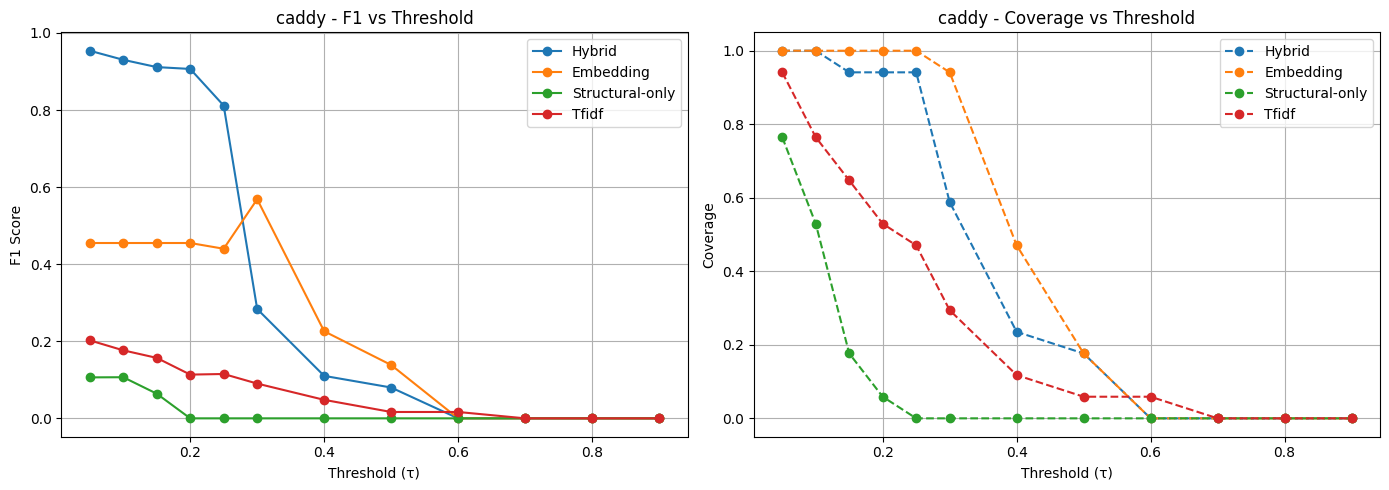

In [10]:
plot_repo_performance("caddy", final_tables)

In [13]:
# COMPUTE THE STATISTICS
import pandas as pd

repos = [
    'caddy', 'json-server', 'requests', 'typer',
    'go-redis', 'fastapi', 'esbuild', 'bubbletea',
    'mitt', 'minisearch'
]

all_data = []

for repo in repos:
    df = final_tables[repo]
    summary = df.groupby('method')['f1'].mean().reset_index()
    summary['repo'] = repo
    all_data.append(summary)

global_df = pd.concat(all_data)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

def plot_threshold_behaviour(final_tables):
    # ---- Combine all repositories ----
    all_dfs = []
    for repo in final_tables:
        df = final_tables[repo].copy()
        df['repo'] = repo
        all_dfs.append(df)

    global_df = pd.concat(all_dfs)

    # Optional: limit threshold for clarity
    global_df = global_df[global_df['threshold'] <= 0.5]

    # ---- Aggregate across repositories ----
    agg_df = (
        global_df
        .groupby(['threshold', 'method'])[['f1', 'recall', 'coverage']]
        .mean()
        .reset_index()
    )

    methods = ['hybrid', 'embedding', 'structural-only', 'tfidf']

    # =========================
    # 🔥 1. F1 vs Threshold
    # =========================
    plt.figure(figsize=(10, 6))

    for method in methods:
        subset = agg_df[agg_df['method'] == method].sort_values('threshold')

        if method == 'hybrid':
            plt.plot(subset['threshold'], subset['f1'],
                     marker='o', linewidth=3, label='Hybrid (Repolens)')
        else:
            plt.plot(subset['threshold'], subset['f1'],
                     marker='o', linestyle='--', alpha=0.7,
                     label=method.replace('-', ' ').title())

    #plt.title("Average F1 Score vs Threshold (All Repositories)")
    plt.xlabel("Threshold (τ)")
    plt.ylabel("Average F1 Score")
    plt.grid(True)
    plt.legend()

    f1_path = "/content/f1_vs_threshold.png"
    plt.savefig(f1_path, dpi=300, bbox_inches='tight')
    plt.show()
    files.download(f1_path)

    # =========================
    # 🔥 2. Coverage vs Threshold
    # =========================
    plt.figure(figsize=(10, 6))

    for method in methods:
        subset = agg_df[agg_df['method'] == method].sort_values('threshold')

        if method == 'hybrid':
            plt.plot(subset['threshold'], subset['coverage'],
                     marker='o', linewidth=3, label='Hybrid (Repolens)')
        else:
            plt.plot(subset['threshold'], subset['coverage'],
                     marker='o', linestyle='--', alpha=0.7,
                     label=method.replace('-', ' ').title())

    #plt.title("Average Coverage vs Threshold (All Repositories)")
    plt.xlabel("Threshold (τ)")
    plt.ylabel("Average Coverage")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()

    cov_path = "/content/coverage_vs_threshold.png"
    plt.savefig(cov_path, dpi=300, bbox_inches='tight')
    plt.show()
    files.download(cov_path)

    # =========================
    # 🔥 3. Recall vs Threshold (Optional)
    # =========================
    plt.figure(figsize=(10, 6))

    for method in methods:
        subset = agg_df[agg_df['method'] == method].sort_values('threshold')

        if method == 'hybrid':
            plt.plot(subset['threshold'], subset['recall'],
                     marker='o', linewidth=3, label='Hybrid (Repolens)')
        else:
            plt.plot(subset['threshold'], subset['recall'],
                     marker='o', linestyle='--', alpha=0.7,
                     label=method.replace('-', ' ').title())

    #plt.title("Average Recall vs Threshold (All Repositories)")
    plt.xlabel("Threshold (τ)")
    plt.ylabel("Average Recall")
    plt.grid(True)
    plt.legend()

    rec_path = "/content/recall_vs_threshold.png"
    plt.savefig(rec_path, dpi=300, bbox_inches='tight')
    plt.show()
    files.download(rec_path)

    print("✅ All threshold behaviour plots generated and downloaded")

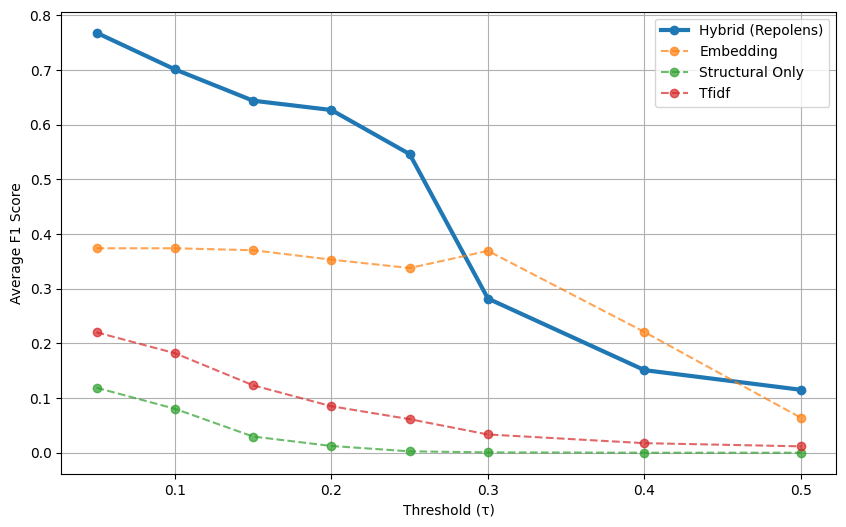

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

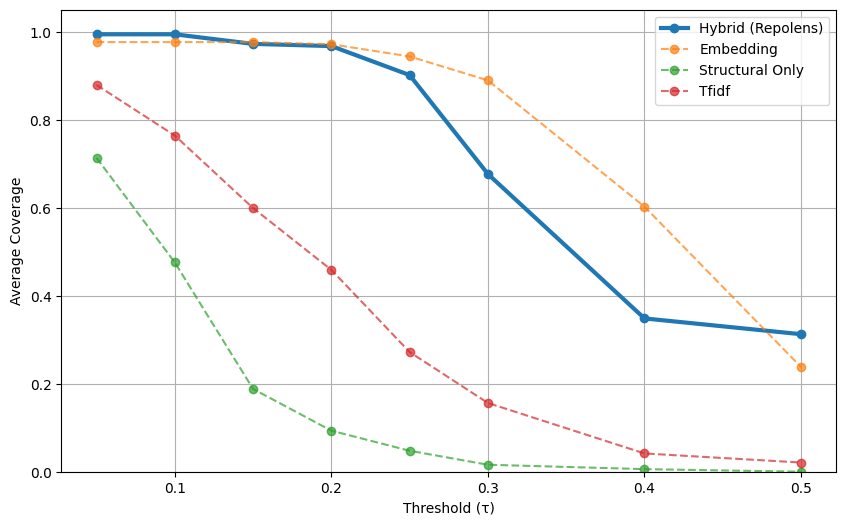

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

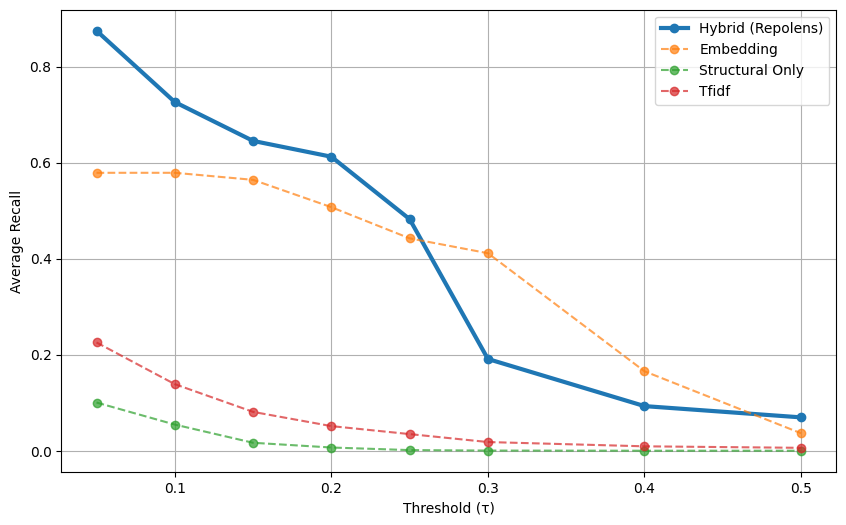

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All threshold behaviour plots generated and downloaded


In [15]:
plot_threshold_behaviour(final_tables)

In [16]:
# MEAN + STANDARD DEVIATION
stats = global_df.groupby('method')['f1'].agg(['mean', 'std']).reset_index()
print(stats)

            method      mean       std
0        embedding  0.205330  0.136858
1           hybrid  0.323701  0.105210
2  structural-only  0.020370  0.014383
3            tfidf  0.061440  0.046065


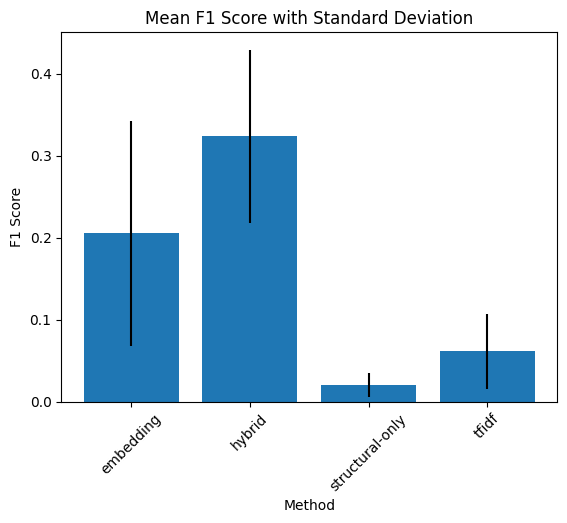

In [17]:
# Error Bar Chart (Mean ± SD)
import matplotlib.pyplot as plt

plt.figure()

plt.bar(stats['method'], stats['mean'], yerr=stats['std'])

plt.xlabel('Method')
plt.ylabel('F1 Score')
plt.title('Mean F1 Score with Standard Deviation')

plt.xticks(rotation=45)
plt.show()

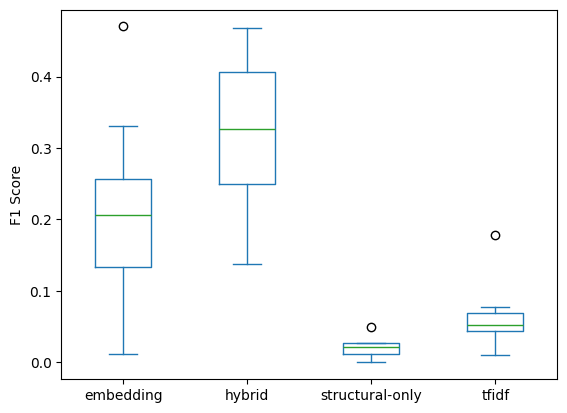

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# BOX PLOT
from google.colab import files

pivot = global_df.pivot(index='repo', columns='method', values='f1')

pivot.plot(kind='box')

#plt.title('F1 Score Distribution Across Repositories')
plt.ylabel('F1 Score')

# ✅ Save
file_path = "/content/f1_distribution_boxplot.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

# ✅ Download
files.download(file_path)

method       diff_hybrid_tfidf  diff_hybrid_embedding  diff_hybrid_structural
repo                                                                         
bubbletea             0.334958               0.152267                0.366908
caddy                 0.337708               0.149575                0.392592
esbuild               0.127425               0.113708                0.126833
fastapi               0.207275               0.214342                0.222983
go-redis              0.268008               0.142042                0.311350
json-server           0.252075               0.105692                0.287158
minisearch            0.229800               0.070425                0.245883
mitt                  0.289175               0.136583                0.417225
requests              0.192058               0.128000                0.241325
typer                 0.384125              -0.028925                0.421050


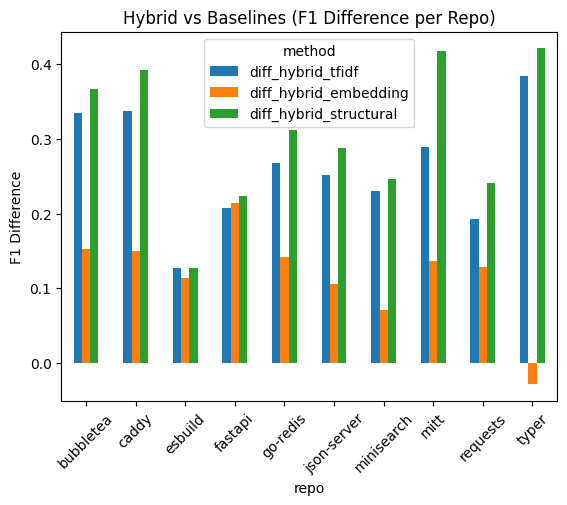

In [19]:
# Paired Differences (Repolens vs Other Baselines)

pivot = global_df.pivot(index='repo', columns='method', values='f1')

pivot['diff_hybrid_tfidf'] = pivot['hybrid'] - pivot['tfidf']
pivot['diff_hybrid_embedding'] = pivot['hybrid'] - pivot['embedding']
pivot['diff_hybrid_structural'] = pivot['hybrid'] - pivot['structural-only']

print(pivot[['diff_hybrid_tfidf', 'diff_hybrid_embedding', 'diff_hybrid_structural']])

pivot[['diff_hybrid_tfidf',
       'diff_hybrid_embedding',
       'diff_hybrid_structural']].plot(kind='bar')

plt.title('Hybrid vs Baselines (F1 Difference per Repo)')
plt.ylabel('F1 Difference')
plt.xticks(rotation=45)

plt.show()

In [20]:
# STATISTICAL SIGNIFICANCE

from scipy.stats import ttest_rel

print("Hybrid vs TF-IDF:", ttest_rel(pivot['hybrid'], pivot['tfidf']))
print("Hybrid vs Embedding:", ttest_rel(pivot['hybrid'], pivot['embedding']))
print("Hybrid vs Structural:", ttest_rel(pivot['hybrid'], pivot['structural-only']))

Hybrid vs TF-IDF: TtestResult(statistic=np.float64(10.719115117390892), pvalue=np.float64(2.0016398657951324e-06), df=np.int64(9))
Hybrid vs Embedding: TtestResult(statistic=np.float64(5.878257024336982), pvalue=np.float64(0.00023533673061796925), df=np.int64(9))
Hybrid vs Structural: TtestResult(statistic=np.float64(9.933731542561741), pvalue=np.float64(3.7817453076653785e-06), df=np.int64(9))


In [22]:
# EFFECT SIZE

import numpy as np

def cohens_d(a, b):
    diff = a - b
    return diff.mean() / diff.std()

print("Hybrid vs TF-IDF:", cohens_d(pivot['hybrid'], pivot['tfidf']))
print("Hybrid vs Embedding:", cohens_d(pivot['hybrid'], pivot['embedding']))
print("Hybrid vs Structural:", cohens_d(pivot['hybrid'], pivot['structural-only']))

Hybrid vs TF-IDF: 3.3896818272498375
Hybrid vs Embedding: 1.8588680868788696
Hybrid vs Structural: 3.141321733915296


In [33]:
pivot = global_df.pivot(index='repo', columns='method', values='f1')
pivot = pivot.dropna()

print(pivot)

method       embedding  hybrid  structural-only   tfidf
repo                                                   
bubbletea       0.4037  0.9505           0.0336  0.1515
caddy           0.4550  0.9304           0.1067  0.1765
esbuild         0.0354  0.2708           0.0561  0.0482
fastapi         0.0181  0.5188           0.0120  0.0732
go-redis        0.2923  0.7243           0.0930  0.1970
json-server     0.4764  0.6382           0.1032  0.2207
minisearch      0.3556  0.4800           0.1157  0.1324
mitt            0.5933  0.8281           0.2198  0.4677
requests        0.2730  0.6854           0.0000  0.1772
typer           0.8365  0.9857           0.0644  0.1766


In [34]:
from scipy.stats import ttest_rel

def cohens_d(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

def compute_stats(name, a, b):
    diff = a - b
    t_stat, p_val = ttest_rel(a, b)

    return {
        "Comparison": name,
        "Mean ΔF1": diff.mean(),
        "Std Dev": diff.std(ddof=1),
        "t-stat": t_stat,
        "p-value": p_val,
        "Effect Size (d)": cohens_d(a, b)
    }

rows = [
    compute_stats("Hybrid vs TF-IDF", pivot['hybrid'], pivot['tfidf']),
    compute_stats("Hybrid vs Embedding", pivot['hybrid'], pivot['embedding']),
    compute_stats("Hybrid vs Structural", pivot['hybrid'], pivot['structural-only']),
]

stats_df = pd.DataFrame(rows).round(4)

stats_df

,Comparison,Mean ΔF1,Std Dev,t-stat,p-value,Effect Size (d)
0,Hybrid vs TF-IDF,0.5191,0.2044,8.0315,0.0000,2.5398
1,Hybrid vs Embedding,0.3273,0.1618,6.3960,0.0001,2.0226
2,Hybrid vs Structural,0.6208,0.2296,8.5480,0.0000,2.7031


In [36]:
import matplotlib.pyplot as plt
from google.colab import files

fig, ax = plt.subplots(figsize=(12, len(stats_df)*0.6))
ax.axis('off')

table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# ---- FIX WIDTH ----
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(1)

    if row == 0:
        cell.set_text_props(weight='bold')

    if col == 0:
        cell.set_width(0.35)
    else:
        cell.set_width(0.13)

file_path = '/content/table_4_13.png'
plt.savefig(file_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.close()

files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# EXPORT STAT TABLE

import matplotlib.pyplot as plt
import os
from google.colab import files

def export_stats_table(df, filename):
    fig, ax = plt.subplots(figsize=(10, 2))  # small height since few rows
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Borders + header styling
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1)
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    plt.savefig(filename, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.close()


# Save
output_path = "/content/statistical_summary.png"
export_stats_table(stats_df, output_path)

print(f"Saved to: {output_path}")

# Download
files.download(output_path)

Saved to: /content/statistical_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import matplotlib.pyplot as plt

def visualize_repo_thresholds(repo, final_tables):
    df = final_tables[repo]

    methods = df['method'].unique()

    n_cols = 2
    n_rows = (len(methods) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()

    for i, method in enumerate(methods):
        method_df = df[df['method'] == method].sort_values(by='threshold')

        x = method_df['threshold']

        axes[i].plot(x, method_df['f1'], marker='o', label='F1')
        axes[i].plot(x, method_df['precision'], marker='o', label='Precision')
        axes[i].plot(x, method_df['recall'], marker='o', label='Recall')

        axes[i].set_title(method)
        axes[i].set_xlabel('Threshold (τ)')
        axes[i].set_ylabel('Score')
        axes[i].legend()
        axes[i].grid(True, linestyle='--', linewidth=0.5)

    # Remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def export_summary_table(final_tables):
    output_dir = '/content/summary_tables'
    os.makedirs(output_dir, exist_ok=True)

    methods = ['hybrid', 'embedding', 'structural-only', 'tfidf']
    method_f1 = {m: [] for m in methods}

    # ---- Collect F1 scores across repositories ----
    for repo, df in final_tables.items():
        # Optional: choose best threshold OR fixed threshold (e.g., 0.1)
        # Here we use threshold = 0.1 (recommended based on your results)
        df_t = df[df['threshold'] == 0.1]

        for method in methods:
            subset = df_t[df_t['method'] == method]
            if not subset.empty:
                f1 = subset['f1'].values[0]
                method_f1[method].append(f1)

    # ---- Compute stats ----
    rows = []
    for method in methods:
        values = method_f1[method]

        mean = np.mean(values)
        std = np.std(values, ddof=1)  # sample std

        rows.append([
            method,
            round(mean, 3),
            round(std, 3)
        ])

    summary_df = pd.DataFrame(rows, columns=["Method", "Mean F1", "Std Dev"])

    # ---- Render table as image ----
    fig, ax = plt.subplots(figsize=(8, len(summary_df)*0.6))
    ax.axis('off')

    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)

    # Styling
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1)
        if row == 0:
            cell.set_text_props(weight='bold')

    file_path = os.path.join(output_dir, "mean_f1_summary.png")

    plt.savefig(file_path, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.close()

    files.download(file_path)

    print("✅ Mean F1 summary table generated!")

In [28]:
export_summary_table(final_tables)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Mean F1 summary table generated!


In [ ]:
repo = 'caddy'
visualize_repo_thresholds( repo, final_tables)

In [ ]:
# STORE VALUES ACROSS ALL THRESHOLDS FOR EACH MATCHER
import os
import matplotlib.pyplot as plt
from google.colab import files

def export_repo_thresholds(repo, final_tables):
    df = final_tables[repo]

    output_dir = f"/content/{repo}_threshold_curves"
    os.makedirs(output_dir, exist_ok=True)

    for method in df['method'].unique():
        method_df = df[df['method'] == method].sort_values(by='threshold')

        x = method_df['threshold']

        plt.figure(figsize=(6, 4))

        plt.plot(x, method_df['f1'], marker='o', label='F1')
        plt.plot(x, method_df['precision'], marker='o', label='Precision')
        plt.plot(x, method_df['recall'], marker='o', label='Recall')

        plt.xlabel('Threshold (τ)')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True, linestyle='--', linewidth=0.5)

        plt.tight_layout()

        file_path = os.path.join(output_dir, f"{repo}_{method}_threshold.png")

        # 🔥 High quality
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        plt.close()

        files.download(file_path)

    print(f"✅ Downloaded all threshold plots for {repo}")

In [ ]:
# EXPORT IMAGE PER REPO
# repos = [
#     'caddy', 'json-server', 'requests', 'typer',
#     'go-redis', 'fastapi', 'esbuild', 'bubbletea',
#     'mitt', 'minisearch'
# ]

name = 'requests'
export_repo_thresholds(name, final_tables)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

def export_grouped_table(repo, final_tables):
    df = final_tables[repo]

    output_dir = f'/content/{repo}_tables'
    os.makedirs(output_dir, exist_ok=True)

    thresholds = sorted([t for t in df['threshold'].unique() if t <= 0.5])

    rows = []

    for t in thresholds:
        row = [t]

        for method in ['hybrid', 'embedding', 'structural-only', 'tfidf']:
            subset = df[(df['threshold'] == t) & (df['method'] == method)]

            if not subset.empty:
                f1 = round(subset['f1'].values[0], 3)
                r = round(subset['recall'].values[0], 3)
                cov = round(subset['coverage'].values[0], 3)

                cell = f"{f1} / {r} / {cov}"
            else:
                cell = "-"

            row.append(cell)

        rows.append(row)

    columns = [
        'τ',
        'Hybrid (F1/R/Cov)',
        'Embedding (F1/R/Cov)',
        'Structural (F1/R/Cov)',
        'TF-IDF (F1/R/Cov)'
    ]

    table_df = pd.DataFrame(rows, columns=columns)

    # ---- Render table as image ----
    fig, ax = plt.subplots(figsize=(14, len(table_df)*0.5))
    ax.axis('off')

    table = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        loc='center',
        cellLoc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.4)

    # Styling
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1)
        if row == 0:
            cell.set_text_props(weight='bold')

    file_path = os.path.join(output_dir, f"{repo}_grouped_table.png")

    plt.savefig(file_path, bbox_inches='tight', pad_inches=0, dpi=300)
    plt.close()

    files.download(file_path)

    print(f"✅ Table generated for {repo}")

In [ ]:
export_grouped_table("fastapi", final_tables)